In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

<h3>CMS pileup data compression based on VQ-VAE compression</h3>

Experiment comments and insights:
* Codebook entries from 256 vectors (rows), only approximately 120 codebook entries are used effectively based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction quality
* Validation set properly works with higher beta coeficient roughly from beta in [0.2, 0.31]
* Codebook plots describe codebook variation, whether certain weights are mostly zero (grey color) and are codebook usage is not sparse (orange colors)
* Making encoded patch d > 2, we do not loose any information and perplexity does not collapse. When latent vector is flat, codebook usage is lower but not harms reconstruction

Utility function import and prepearation

In [3]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

<h3>Helper objects</h3>

In [4]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

<h3>Helper constants</h3>

In [5]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

<h3>Data loading</h3>

In [6]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 237.62it/s]


<h3>VQ-VAE Hyperparameters</h3>

In [7]:
batch_size = 320
beta = 0.6
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 4e-4
model_param_scale = 1
# model_param_scale = 1 (right order)

num_epochs = 200
# num_epochs = 1

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 512
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# Residual layer config
residual_channels = 32
residual_layers = 2

# Latent dimension size
d = 1 # adjustable encoder width for extra compression

decay = 0.888
epsilon = 1e-4
use_ema = True


In [8]:
def _get_codebook_usage(encodings: torch.tensor) -> None:
    encodings_uniq = torch.unique(encodings)
    used_encodings = len(encodings_uniq)
    usage = (used_encodings * 100) / num_embeddings
    return usage
    # print(f"Codeword utilization: {usage:.3f} %")


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [10]:
mse = MeanSquaredError()
mse = mse.to(device)

In [11]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [12]:
event_train = events_train[:SELECTED_EVENTS][0]

In [13]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


<h3>Data preprocessing</h3>

<h3>Data loading</h3>

In [14]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


<h3>VAE Binary Cross Entropy loss for VQ-VAE</h3>

In [15]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

<h3>VQ-VAE model</h3>

In [16]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta, decay, epsilon):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        
        # commitment loss
        self.beta = beta
        self.decay = decay

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        # self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)
        # self.embedding.weight.data.normal_()
        # self.ema_weights.data.normal_()
        self.register_buffer("ema_weights", torch.randn(n_e, e_dim))
        self.embedding.weight.data.uniform_(
            -1 / n_e,
            1 / n_e
        )
        self.ema_weights.data.copy_(self.embedding.weight.data)
        self.register_buffer('ema_cluster_size', torch.zeros(n_e))
        
        self.decay = decay
        self.epsilon = epsilon

    def forward(self, z, indexes: int, use_ema: bool):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        # z = z.permute(0, 2, 3, 1).contiguous()
        # z_flattened = z.view(-1, self.e_dim).contiguous()
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e
        ).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        if use_ema and self.training:
            
            # List that holds all the averaged points
            # shrinks passed clusters and gives more attention to the recent ema_cluster_size * decay
            # decay helps to determina which parts contribute more
            self.ema_cluster_size.mul_(self.decay).add_(
                (1 - self.decay) * torch.sum(min_encodings, 0)
            )
            
            # n_e * epsilon ensures that each cluster has some size and no 0
            # dat normalization
            total_cluster_size = self.ema_cluster_size.sum(dim=-1, keepdim=True)
            
            # normalizes data from 0 to 1
            self.ema_cluster_size = (
                (self.ema_cluster_size + self.epsilon)
                / (total_cluster_size + self.n_e * self.epsilon) * total_cluster_size)
            dw = torch.matmul(min_encodings.t(), z.detach())
            
            with torch.no_grad():
                self.ema_weights.mul_(self.decay).add_((1-self.decay) * dw)

                self.embedding.weight.copy_(
                    self.ema_weights /
                    self.ema_cluster_size.unsqueeze(1)
                )
            # self.ema_weights.data = self.ema_weights * self.decay + (1 - self.decay) * dw
            # self.embedding.weight.data = self.ema_weights / self.ema_cluster_size.unsqueeze(1)
        
        # compute loss for embedding
        vq_loss = torch.mean((z_q.detach() - z)**2)
        
        if use_ema:
            loss = (
                self.beta * vq_loss
            )
        else:
            commitment_loss = torch.mean((z_q - z.detach())**2)
            loss = (
                vq_loss + self.beta * commitment_loss
            )
        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # e_mean - embeddings mean
        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))
        
        z_q = z_q.reshape(-1, indexes, self.e_dim)

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [17]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [18]:
# TODO: think about it later
class AbstractModule(nn.Module):
    
    def __init__(self) -> None:
        super().__init__()
    
    def forward(self, x: torch.tensor) -> None:
        raise NotImplemented

In [19]:
# TODO: test with 2 x 2 encoded patch

class EncoderInput(AbstractModule):
    
    # NOTE: encoder_features - from convolution network
    """
    indexes: int - how many codebook indexes could an encoded patch have    
    encoder_features: int - how many features are in encoder convolution output 
    
    """
    def __init__(self, indexes: int, slope: np.float64, latent_dim: int, encoder_features: int = 4) -> None:
        super().__init__()
        
        # TODO: in_features need to come from encoder conv network
        self.encoder_features = encoder_features
        self.layers = nn.Sequential(
            nn.Linear(in_features=encoder_features, out_features=indexes),
            nn.BatchNorm1d(latent_dim),
            nn.LeakyReLU(slope)
        )
        
    def forward(self, x: torch.tensor) -> None:
        b, c, w, h = x.shape
        x_flattened = x.reshape(b, c, w * h)
        x_output = self.layers(x_flattened)
        (b, c, w) = x_output.shape
        x_output_flattened = x_output.reshape(b * w, c)
        return x_output_flattened.contiguous()
    

class DecoderInput(AbstractModule):
    
    # NOTE: decoder_features - dinamically add required feature count for decoder
    
    """
    d: int - how many indexes could an encoded patch have
    decoder_features: int - how many features could a decoder convolution network have
    """
    
    def __init__(
        self, 
        indexes: int, 
        slope: np.float64, 
        decoder_features: int = 4,
    ) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=indexes, out_features=decoder_features),
            nn.BatchNorm1d(latent_dim),
            nn.LeakyReLU(slope)
        )
        self.decoder_features = decoder_features
        
    def forward(self, x: torch.tensor) -> None:
        (b, w, c) = x.shape
        x = x.reshape(b, c, w)
        dec_out = self.layers(x)
        
        dec_out = dec_out.reshape(
            b,
            c,
            self.decoder_features//2,
            self.decoder_features//2
        )
        return dec_out
    

In [20]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        d: int,
        residual_slope: float = 0.08,
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(   
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        # fully connected layer for encoder input
        self.fc_encoder_input = EncoderInput(indexes=d, slope=slope, latent_dim=latent_dim)     
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta, decay, epsilon)
        
        # fully connected layer for vq input
        self.fc_decoder_input = DecoderInput(indexes=d, slope=slope)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x, indexes):
        encoder_output = self.encoder(x)
        
        z = self.fc_encoder_input(encoder_output)
        # (b, c, d) -> (b * d, c)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z, indexes, use_ema=use_ema)
        
        usage = _get_codebook_usage(min_encoding_indices)
        
        output_decoder_input = self.fc_decoder_input(z_q)
        
        output = self.decoder(output_decoder_input)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss,
            usage
        )

In [21]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    d=d, # encoded patch indexes
    n_res_layers=residual_layers, # residual hidden layers
    res_h_dim=residual_channels # residual hidden channels
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

<h3>VQ-VAE training loop</h3>

Epoch 1/200: 100%|██████████| 40/40 [00:00<00:00, 100.72it/s, Loss (BCE + VQ)=0.0849]


Epoch [1/200] summary:Average Loss: VQ + BCE = 0.1683,  Average loss: BCE = 0.1446 MSE = 0.02687415360705927 avg_perplexity = 51.59865427017212
Average validation set BCE loss: 0.08376390486955643
Before compression (Training)
Shape: (205, 8, 8)


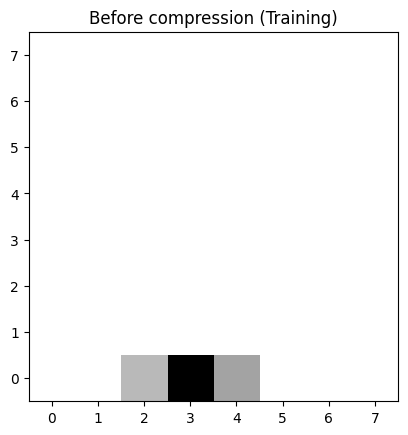

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 11.914 %


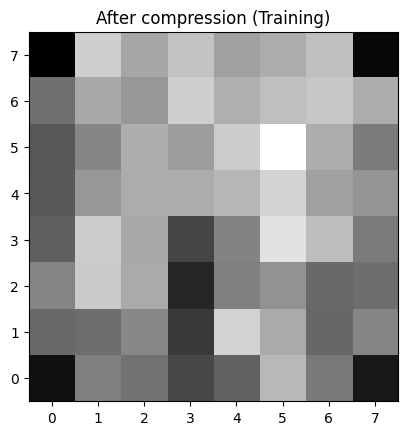

Epoch 2/200: 100%|██████████| 40/40 [00:00<00:00, 209.66it/s, Loss (BCE + VQ)=0.0818]


Epoch [2/200] summary:Average Loss: VQ + BCE = 0.0866,  Average loss: BCE = 0.0820 MSE = 0.00835034407209605 avg_perplexity = 52.882859802246095
Average validation set BCE loss: 0.07423653453588486


Epoch 3/200: 100%|██████████| 40/40 [00:00<00:00, 224.68it/s, Loss (BCE + VQ)=0.0703]


Epoch [3/200] summary:Average Loss: VQ + BCE = 0.0734,  Average loss: BCE = 0.0699 MSE = 0.0074841300258412955 avg_perplexity = 53.41351690292358
Average validation set BCE loss: 0.0641527846455574


Epoch 4/200: 100%|██████████| 40/40 [00:00<00:00, 222.83it/s, Loss (BCE + VQ)=0.0574]


...

Epoch [14/200] summary:Average Loss: VQ + BCE = 0.0558,  Average loss: BCE = 0.0498 MSE = 0.005025540105998516 avg_perplexity = 60.03464241027832
Average validation set BCE loss: 0.048203274607658386


Epoch 15/200: 100%|██████████| 40/40 [00:00<00:00, 197.07it/s, Loss (BCE + VQ)=0.0549]


Epoch [15/200] summary:Average Loss: VQ + BCE = 0.0557,  Average loss: BCE = 0.0496 MSE = 0.0050076076644472774 avg_perplexity = 60.37978172302246
Average validation set BCE loss: 0.0478646494448185


Epoch 16/200: 100%|██████████| 40/40 [00:00<00:00, 211.17it/s, Loss (BCE + VQ)=0.052] 


Epoch [16/200] summary:Average Loss: VQ + BCE = 0.0555,  Average loss: BCE = 0.0494 MSE = 0.004966254089958965 avg_perplexity = 60.771873474121094
Average validation set BCE loss: 0.04755686968564987
Before compression (Training)
Shape: (205, 8, 8)


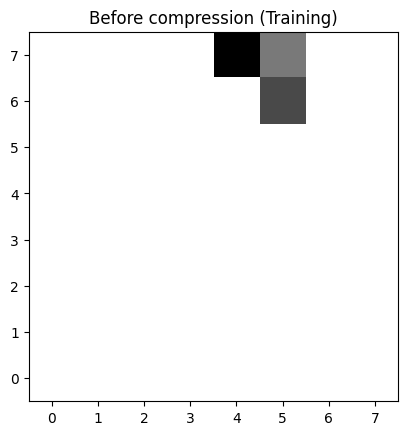

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 13.281 %


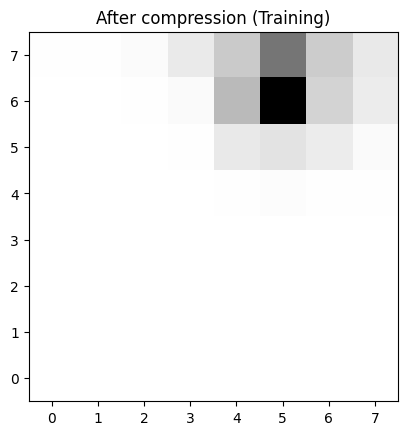

Epoch 17/200: 100%|██████████| 40/40 [00:00<00:00, 217.71it/s, Loss (BCE + VQ)=0.0522]


Epoch [17/200] summary:Average Loss: VQ + BCE = 0.0552,  Average loss: BCE = 0.0491 MSE = 0.004935346601996571 avg_perplexity = 60.566265773773196
Average validation set BCE loss: 0.047402676194906235


Epoch 18/200: 100%|██████████| 40/40 [00:00<00:00, 228.36it/s, Loss (BCE + VQ)=0.0573]


Epoch [18/200] summary:Average Loss: VQ + BCE = 0.0552,  Average loss: BCE = 0.0490 MSE = 0.004900267790071666 avg_perplexity = 60.4129656791687
Average validation set BCE loss: 0.047620661556720734


Epoch 19/200: 100%|██████████| 40/40 [00:00<00:00, 228.31it/s, Loss (BCE + VQ)=0.0538]


...

Epoch [29/200] summary:Average Loss: VQ + BCE = 0.0544,  Average loss: BCE = 0.0483 MSE = 0.004879453766625375 avg_perplexity = 60.63833103179932
Average validation set BCE loss: 0.04666610062122345


Epoch 30/200: 100%|██████████| 40/40 [00:00<00:00, 223.11it/s, Loss (BCE + VQ)=0.0634]


Epoch [30/200] summary:Average Loss: VQ + BCE = 0.0543,  Average loss: BCE = 0.0483 MSE = 0.004895948769990355 avg_perplexity = 60.54024782180786
Average validation set BCE loss: 0.04704336076974869


Epoch 31/200: 100%|██████████| 40/40 [00:00<00:00, 211.81it/s, Loss (BCE + VQ)=0.0526]


Epoch [31/200] summary:Average Loss: VQ + BCE = 0.0542,  Average loss: BCE = 0.0481 MSE = 0.004861193685792386 avg_perplexity = 60.850451946258545
Average validation set BCE loss: 0.046456389129161835
Before compression (Training)
Shape: (205, 8, 8)


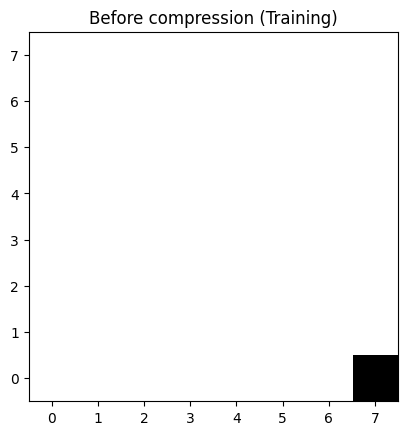

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 12.500 %


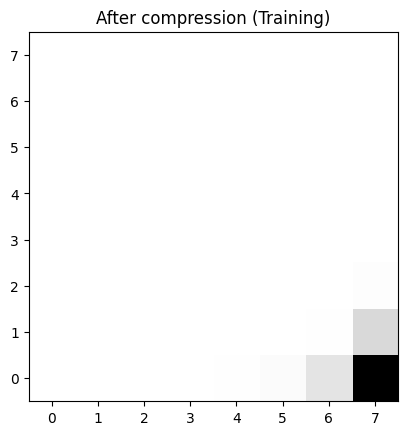

Epoch 32/200: 100%|██████████| 40/40 [00:00<00:00, 222.54it/s, Loss (BCE + VQ)=0.0534]


Epoch [32/200] summary:Average Loss: VQ + BCE = 0.0541,  Average loss: BCE = 0.0482 MSE = 0.004866914532613009 avg_perplexity = 60.95401563644409
Average validation set BCE loss: 0.046622615307569504


Epoch 33/200: 100%|██████████| 40/40 [00:00<00:00, 225.22it/s, Loss (BCE + VQ)=0.0563]


Epoch [33/200] summary:Average Loss: VQ + BCE = 0.0540,  Average loss: BCE = 0.0481 MSE = 0.004878651979379356 avg_perplexity = 60.651894664764406
Average validation set BCE loss: 0.04653366282582283


Epoch 34/200: 100%|██████████| 40/40 [00:00<00:00, 239.04it/s, Loss (BCE + VQ)=0.0525]


...

Epoch [44/200] summary:Average Loss: VQ + BCE = 0.0538,  Average loss: BCE = 0.0479 MSE = 0.004878360888687894 avg_perplexity = 60.966487121582034
Average validation set BCE loss: 0.04652544856071472


Epoch 45/200: 100%|██████████| 40/40 [00:00<00:00, 225.45it/s, Loss (BCE + VQ)=0.0603]


Epoch [45/200] summary:Average Loss: VQ + BCE = 0.0536,  Average loss: BCE = 0.0479 MSE = 0.00486156169208698 avg_perplexity = 60.7414270401001
Average validation set BCE loss: 0.04639042168855667


Epoch 46/200: 100%|██████████| 40/40 [00:00<00:00, 223.05it/s, Loss (BCE + VQ)=0.0487]


Epoch [46/200] summary:Average Loss: VQ + BCE = 0.0534,  Average loss: BCE = 0.0477 MSE = 0.004865644092205912 avg_perplexity = 61.0042631149292
Average validation set BCE loss: 0.046208903193473816
Before compression (Training)
Shape: (205, 8, 8)


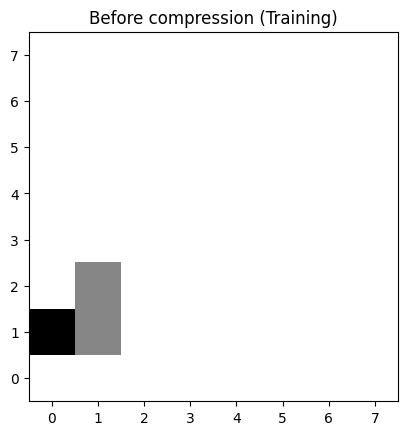

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 12.500 %


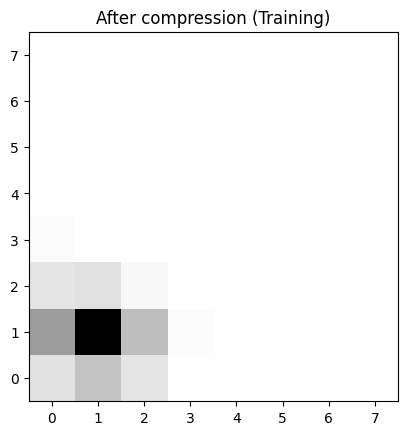

Epoch 47/200: 100%|██████████| 40/40 [00:00<00:00, 209.16it/s, Loss (BCE + VQ)=0.0626]


Epoch [47/200] summary:Average Loss: VQ + BCE = 0.0536,  Average loss: BCE = 0.0479 MSE = 0.004877110291272402 avg_perplexity = 60.743306922912595
Average validation set BCE loss: 0.04630022868514061


Epoch 48/200: 100%|██████████| 40/40 [00:00<00:00, 220.06it/s, Loss (BCE + VQ)=0.0488]


Epoch [48/200] summary:Average Loss: VQ + BCE = 0.0533,  Average loss: BCE = 0.0477 MSE = 0.004854702937882394 avg_perplexity = 60.67269763946533
Average validation set BCE loss: 0.046099599450826645


Epoch 49/200: 100%|██████████| 40/40 [00:00<00:00, 233.06it/s, Loss (BCE + VQ)=0.0579]


...

Epoch [59/200] summary:Average Loss: VQ + BCE = 0.0530,  Average loss: BCE = 0.0476 MSE = 0.004854347510263324 avg_perplexity = 60.895083618164065
Average validation set BCE loss: 0.04621673747897148


Epoch 60/200: 100%|██████████| 40/40 [00:00<00:00, 208.92it/s, Loss (BCE + VQ)=0.0593]


Epoch [60/200] summary:Average Loss: VQ + BCE = 0.0531,  Average loss: BCE = 0.0477 MSE = 0.004876026569399982 avg_perplexity = 60.988397407531735
Average validation set BCE loss: 0.04618658125400543


Epoch 61/200: 100%|██████████| 40/40 [00:00<00:00, 217.83it/s, Loss (BCE + VQ)=0.05]  


Epoch [61/200] summary:Average Loss: VQ + BCE = 0.0531,  Average loss: BCE = 0.0477 MSE = 0.004872308601625264 avg_perplexity = 60.60256996154785
Average validation set BCE loss: 0.04618128389120102
Before compression (Training)
Shape: (205, 8, 8)


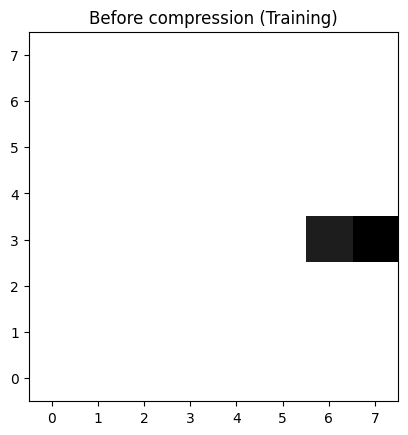

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 12.305 %


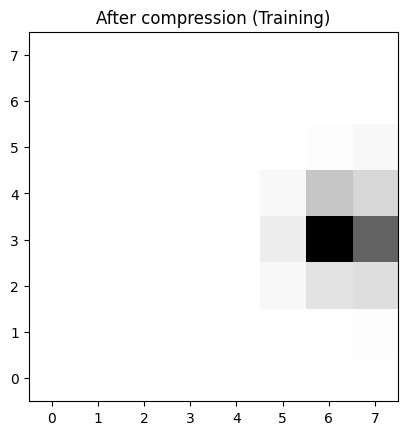

Epoch 62/200: 100%|██████████| 40/40 [00:00<00:00, 219.61it/s, Loss (BCE + VQ)=0.0595]


Epoch [62/200] summary:Average Loss: VQ + BCE = 0.0531,  Average loss: BCE = 0.0477 MSE = 0.0048755401279777285 avg_perplexity = 60.72978401184082
Average validation set BCE loss: 0.04626239836215973


Epoch 63/200: 100%|██████████| 40/40 [00:00<00:00, 201.94it/s, Loss (BCE + VQ)=0.0543]


Epoch [63/200] summary:Average Loss: VQ + BCE = 0.0530,  Average loss: BCE = 0.0477 MSE = 0.004873694339767099 avg_perplexity = 60.874275588989256
Average validation set BCE loss: 0.046281345188617706


Epoch 64/200: 100%|██████████| 40/40 [00:00<00:00, 222.13it/s, Loss (BCE + VQ)=0.0503]


...

Epoch [74/200] summary:Average Loss: VQ + BCE = 0.0527,  Average loss: BCE = 0.0476 MSE = 0.004877109138760716 avg_perplexity = 60.92338018417358
Average validation set BCE loss: 0.0461273267865181


Epoch 75/200: 100%|██████████| 40/40 [00:00<00:00, 222.02it/s, Loss (BCE + VQ)=0.0559]


Epoch [75/200] summary:Average Loss: VQ + BCE = 0.0527,  Average loss: BCE = 0.0476 MSE = 0.004873961460543796 avg_perplexity = 60.74870929718018
Average validation set BCE loss: 0.046098656952381134


Epoch 76/200: 100%|██████████| 40/40 [00:00<00:00, 231.64it/s, Loss (BCE + VQ)=0.048] 


Epoch [76/200] summary:Average Loss: VQ + BCE = 0.0526,  Average loss: BCE = 0.0475 MSE = 0.004867300798650831 avg_perplexity = 60.969356060028076
Average validation set BCE loss: 0.045952457934617996
Before compression (Training)
Shape: (205, 8, 8)


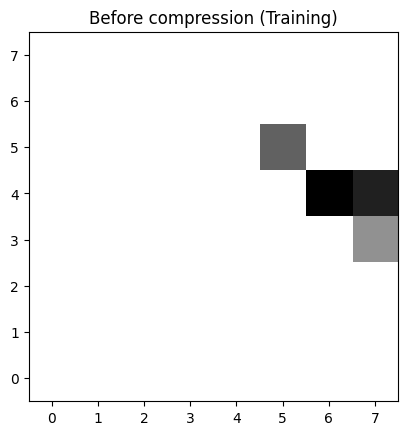

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 13.086 %


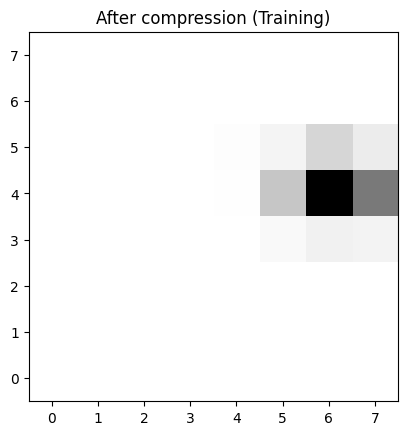

Epoch 77/200: 100%|██████████| 40/40 [00:00<00:00, 221.82it/s, Loss (BCE + VQ)=0.0532]


Epoch [77/200] summary:Average Loss: VQ + BCE = 0.0527,  Average loss: BCE = 0.0475 MSE = 0.004866525676334277 avg_perplexity = 60.95517368316651
Average validation set BCE loss: 0.04620440676808357


Epoch 78/200: 100%|██████████| 40/40 [00:00<00:00, 213.34it/s, Loss (BCE + VQ)=0.0581]


Epoch [78/200] summary:Average Loss: VQ + BCE = 0.0527,  Average loss: BCE = 0.0476 MSE = 0.004879967961460352 avg_perplexity = 61.023371410369876
Average validation set BCE loss: 0.046108588576316833


Epoch 79/200: 100%|██████████| 40/40 [00:00<00:00, 225.00it/s, Loss (BCE + VQ)=0.0512]


...

Epoch [89/200] summary:Average Loss: VQ + BCE = 0.0523,  Average loss: BCE = 0.0475 MSE = 0.00488684750162065 avg_perplexity = 61.08202266693115
Average validation set BCE loss: 0.04589422792196274


Epoch 90/200: 100%|██████████| 40/40 [00:00<00:00, 213.54it/s, Loss (BCE + VQ)=0.0513]


Epoch [90/200] summary:Average Loss: VQ + BCE = 0.0523,  Average loss: BCE = 0.0475 MSE = 0.0048696445534005765 avg_perplexity = 60.884642887115476
Average validation set BCE loss: 0.045849550515413284


Epoch 91/200: 100%|██████████| 40/40 [00:00<00:00, 229.13it/s, Loss (BCE + VQ)=0.0518]


Epoch [91/200] summary:Average Loss: VQ + BCE = 0.0523,  Average loss: BCE = 0.0474 MSE = 0.004872935614548624 avg_perplexity = 60.82694234848022
Average validation set BCE loss: 0.045892275869846344
Before compression (Training)
Shape: (205, 8, 8)


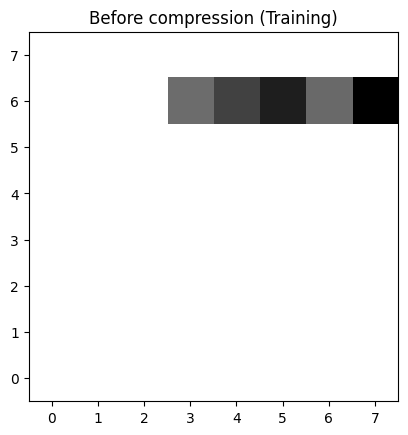

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 12.891 %


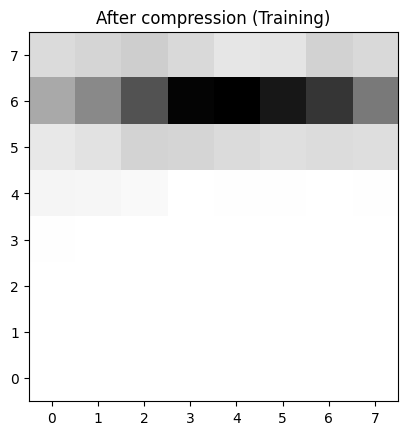

Epoch 92/200: 100%|██████████| 40/40 [00:00<00:00, 221.71it/s, Loss (BCE + VQ)=0.0505]


Epoch [92/200] summary:Average Loss: VQ + BCE = 0.0523,  Average loss: BCE = 0.0474 MSE = 0.004877266113180667 avg_perplexity = 60.57529850006104
Average validation set BCE loss: 0.04611026123166084


Epoch 93/200: 100%|██████████| 40/40 [00:00<00:00, 227.42it/s, Loss (BCE + VQ)=0.0526]


Epoch [93/200] summary:Average Loss: VQ + BCE = 0.0523,  Average loss: BCE = 0.0474 MSE = 0.004875539249042049 avg_perplexity = 60.754587745666505
Average validation set BCE loss: 0.04607727378606796


Epoch 94/200: 100%|██████████| 40/40 [00:00<00:00, 199.91it/s, Loss (BCE + VQ)=0.0546]


...

Epoch [104/200] summary:Average Loss: VQ + BCE = 0.0521,  Average loss: BCE = 0.0475 MSE = 0.004879889037692919 avg_perplexity = 60.683852195739746
Average validation set BCE loss: 0.04612289369106293


Epoch 105/200: 100%|██████████| 40/40 [00:00<00:00, 214.33it/s, Loss (BCE + VQ)=0.0581]


Epoch [105/200] summary:Average Loss: VQ + BCE = 0.0522,  Average loss: BCE = 0.0475 MSE = 0.0048841227311640974 avg_perplexity = 61.035012340545656
Average validation set BCE loss: 0.04598318785429001


Epoch 106/200: 100%|██████████| 40/40 [00:00<00:00, 219.68it/s, Loss (BCE + VQ)=0.0557]


Epoch [106/200] summary:Average Loss: VQ + BCE = 0.0522,  Average loss: BCE = 0.0475 MSE = 0.00488917282782495 avg_perplexity = 60.94376831054687
Average validation set BCE loss: 0.04598712548613548
Before compression (Training)
Shape: (205, 8, 8)


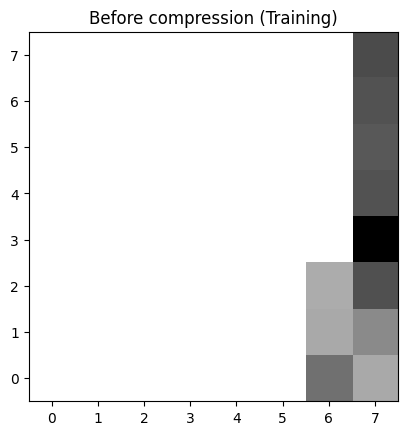

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 12.305 %


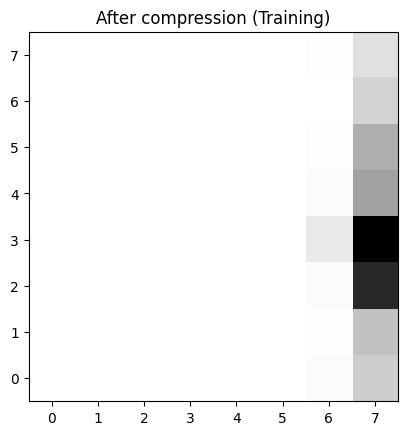

Epoch 107/200: 100%|██████████| 40/40 [00:00<00:00, 218.79it/s, Loss (BCE + VQ)=0.0496]


Epoch [107/200] summary:Average Loss: VQ + BCE = 0.0520,  Average loss: BCE = 0.0474 MSE = 0.004872932913713157 avg_perplexity = 60.63491973876953
Average validation set BCE loss: 0.04608157277107239


Epoch 108/200: 100%|██████████| 40/40 [00:00<00:00, 216.77it/s, Loss (BCE + VQ)=0.0472]


Epoch [108/200] summary:Average Loss: VQ + BCE = 0.0519,  Average loss: BCE = 0.0474 MSE = 0.004875093942973763 avg_perplexity = 61.035445022583005
Average validation set BCE loss: 0.04597663879394531


Epoch 109/200: 100%|██████████| 40/40 [00:00<00:00, 219.89it/s, Loss (BCE + VQ)=0.052] 


...

Epoch [119/200] summary:Average Loss: VQ + BCE = 0.0518,  Average loss: BCE = 0.0474 MSE = 0.004887778463307768 avg_perplexity = 60.403096961975095
Average validation set BCE loss: 0.04590783640742302


Epoch 120/200: 100%|██████████| 40/40 [00:00<00:00, 220.88it/s, Loss (BCE + VQ)=0.0493]


Epoch [120/200] summary:Average Loss: VQ + BCE = 0.0519,  Average loss: BCE = 0.0474 MSE = 0.004891796072479337 avg_perplexity = 60.81634883880615
Average validation set BCE loss: 0.045946307480335236


Epoch 121/200: 100%|██████████| 40/40 [00:00<00:00, 219.78it/s, Loss (BCE + VQ)=0.0482]


Epoch [121/200] summary:Average Loss: VQ + BCE = 0.0519,  Average loss: BCE = 0.0474 MSE = 0.004890369880013168 avg_perplexity = 60.61522760391235
Average validation set BCE loss: 0.04615603759884834
Before compression (Training)
Shape: (205, 8, 8)


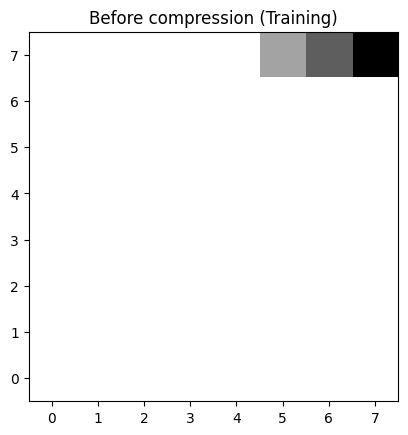

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 12.891 %


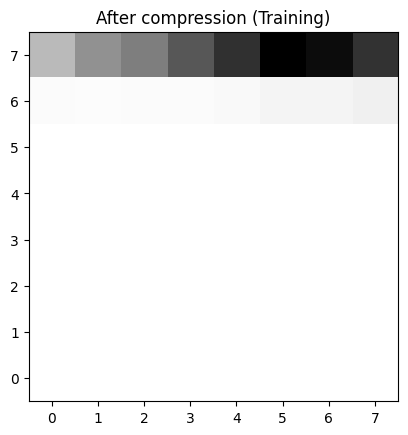

Epoch 122/200: 100%|██████████| 40/40 [00:00<00:00, 221.00it/s, Loss (BCE + VQ)=0.0581]


Epoch [122/200] summary:Average Loss: VQ + BCE = 0.0519,  Average loss: BCE = 0.0475 MSE = 0.004893296281807125 avg_perplexity = 60.59908332824707
Average validation set BCE loss: 0.0460580438375473


Epoch 123/200: 100%|██████████| 40/40 [00:00<00:00, 202.15it/s, Loss (BCE + VQ)=0.0571]


Epoch [123/200] summary:Average Loss: VQ + BCE = 0.0520,  Average loss: BCE = 0.0475 MSE = 0.004907196579733863 avg_perplexity = 60.88287086486817
Average validation set BCE loss: 0.0462154746055603


Epoch 124/200: 100%|██████████| 40/40 [00:00<00:00, 210.87it/s, Loss (BCE + VQ)=0.0547]


...

Epoch [134/200] summary:Average Loss: VQ + BCE = 0.0517,  Average loss: BCE = 0.0474 MSE = 0.004898064595181495 avg_perplexity = 60.531369876861575
Average validation set BCE loss: 0.04598988965153694


Epoch 135/200: 100%|██████████| 40/40 [00:00<00:00, 224.38it/s, Loss (BCE + VQ)=0.051] 


Epoch [135/200] summary:Average Loss: VQ + BCE = 0.0517,  Average loss: BCE = 0.0474 MSE = 0.004898490576306358 avg_perplexity = 60.79800157546997
Average validation set BCE loss: 0.04608697071671486


Epoch 136/200: 100%|██████████| 40/40 [00:00<00:00, 208.31it/s, Loss (BCE + VQ)=0.0468]


Epoch [136/200] summary:Average Loss: VQ + BCE = 0.0517,  Average loss: BCE = 0.0474 MSE = 0.004906600806862116 avg_perplexity = 60.80543584823609
Average validation set BCE loss: 0.04620320722460747
Before compression (Training)
Shape: (205, 8, 8)


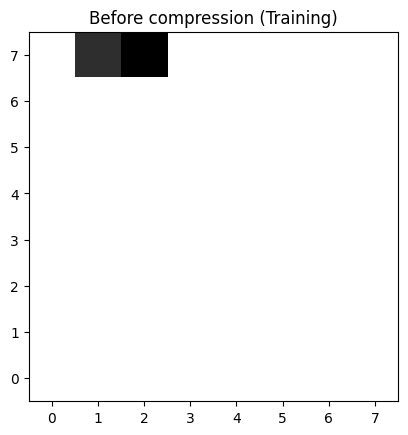

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 13.281 %


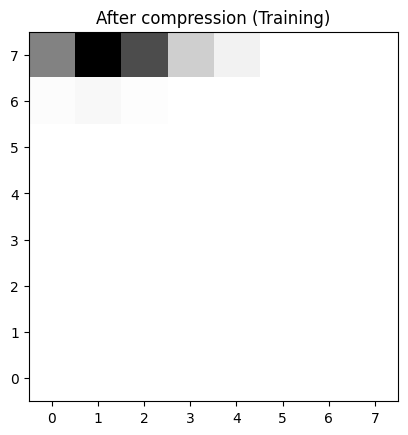

Epoch 137/200: 100%|██████████| 40/40 [00:00<00:00, 223.72it/s, Loss (BCE + VQ)=0.0596]


Epoch [137/200] summary:Average Loss: VQ + BCE = 0.0518,  Average loss: BCE = 0.0474 MSE = 0.004908596823224798 avg_perplexity = 60.90979642868042
Average validation set BCE loss: 0.04590509831905365


Epoch 138/200: 100%|██████████| 40/40 [00:00<00:00, 221.26it/s, Loss (BCE + VQ)=0.0526]


Epoch [138/200] summary:Average Loss: VQ + BCE = 0.0516,  Average loss: BCE = 0.0474 MSE = 0.004904932843055576 avg_perplexity = 60.78033390045166
Average validation set BCE loss: 0.04606391862034798


Epoch 139/200: 100%|██████████| 40/40 [00:00<00:00, 221.94it/s, Loss (BCE + VQ)=0.0517]


...

Epoch [149/200] summary:Average Loss: VQ + BCE = 0.0517,  Average loss: BCE = 0.0474 MSE = 0.004901054222136736 avg_perplexity = 61.04477157592773
Average validation set BCE loss: 0.046037837862968445


Epoch 150/200: 100%|██████████| 40/40 [00:00<00:00, 212.98it/s, Loss (BCE + VQ)=0.0538]


Epoch [150/200] summary:Average Loss: VQ + BCE = 0.0516,  Average loss: BCE = 0.0474 MSE = 0.004910891654435545 avg_perplexity = 60.808805274963376
Average validation set BCE loss: 0.045961108058691025


Epoch 151/200: 100%|██████████| 40/40 [00:00<00:00, 212.38it/s, Loss (BCE + VQ)=0.0531]


Epoch [151/200] summary:Average Loss: VQ + BCE = 0.0516,  Average loss: BCE = 0.0474 MSE = 0.004893570044077933 avg_perplexity = 60.64143886566162
Average validation set BCE loss: 0.046162717044353485
Before compression (Training)
Shape: (205, 8, 8)


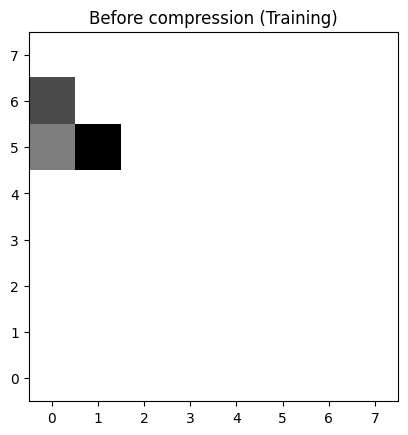

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 13.281 %


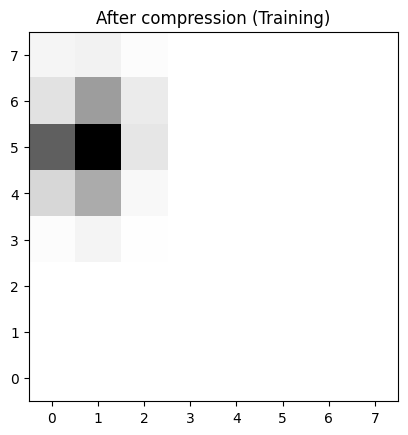

Epoch 152/200: 100%|██████████| 40/40 [00:00<00:00, 217.30it/s, Loss (BCE + VQ)=0.0518]


Epoch [152/200] summary:Average Loss: VQ + BCE = 0.0515,  Average loss: BCE = 0.0474 MSE = 0.0049158892361447215 avg_perplexity = 60.96327228546143
Average validation set BCE loss: 0.04595353081822395


Epoch 153/200: 100%|██████████| 40/40 [00:00<00:00, 218.63it/s, Loss (BCE + VQ)=0.049] 


Epoch [153/200] summary:Average Loss: VQ + BCE = 0.0515,  Average loss: BCE = 0.0474 MSE = 0.0049045569961890575 avg_perplexity = 60.79967317581177
Average validation set BCE loss: 0.04603179171681404


Epoch 154/200: 100%|██████████| 40/40 [00:00<00:00, 213.05it/s, Loss (BCE + VQ)=0.0526]


...

Epoch [164/200] summary:Average Loss: VQ + BCE = 0.0516,  Average loss: BCE = 0.0474 MSE = 0.004929292656015605 avg_perplexity = 60.676334381103516
Average validation set BCE loss: 0.04585497826337814


Epoch 165/200: 100%|██████████| 40/40 [00:00<00:00, 223.57it/s, Loss (BCE + VQ)=0.0504]


Epoch [165/200] summary:Average Loss: VQ + BCE = 0.0514,  Average loss: BCE = 0.0474 MSE = 0.004921821819152683 avg_perplexity = 60.78628921508789
Average validation set BCE loss: 0.04591779410839081


Epoch 166/200: 100%|██████████| 40/40 [00:00<00:00, 230.32it/s, Loss (BCE + VQ)=0.0583]


Epoch [166/200] summary:Average Loss: VQ + BCE = 0.0515,  Average loss: BCE = 0.0475 MSE = 0.004919892526231706 avg_perplexity = 60.63795404434204
Average validation set BCE loss: 0.04605840519070625
Before compression (Training)
Shape: (205, 8, 8)


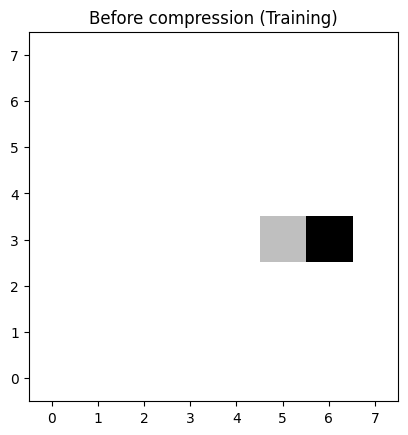

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 12.891 %


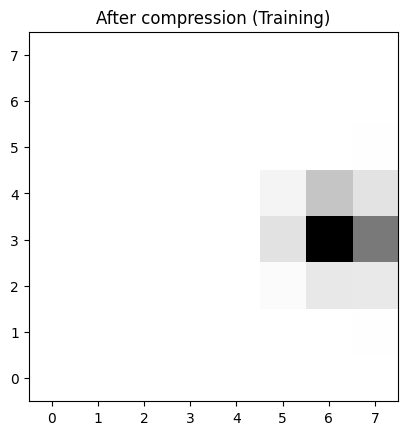

Epoch 167/200: 100%|██████████| 40/40 [00:00<00:00, 217.43it/s, Loss (BCE + VQ)=0.0515]


Epoch [167/200] summary:Average Loss: VQ + BCE = 0.0514,  Average loss: BCE = 0.0474 MSE = 0.004911908193025738 avg_perplexity = 61.00614728927612
Average validation set BCE loss: 0.04593861475586891


Epoch 168/200: 100%|██████████| 40/40 [00:00<00:00, 210.21it/s, Loss (BCE + VQ)=0.0498]


Epoch [168/200] summary:Average Loss: VQ + BCE = 0.0514,  Average loss: BCE = 0.0474 MSE = 0.004907971527427435 avg_perplexity = 61.11668739318848
Average validation set BCE loss: 0.04604848846793175


Epoch 169/200: 100%|██████████| 40/40 [00:00<00:00, 215.69it/s, Loss (BCE + VQ)=0.0506]


...

Epoch [179/200] summary:Average Loss: VQ + BCE = 0.0515,  Average loss: BCE = 0.0474 MSE = 0.00492064084392041 avg_perplexity = 60.717983436584475
Average validation set BCE loss: 0.04587392136454582


Epoch 180/200: 100%|██████████| 40/40 [00:00<00:00, 218.62it/s, Loss (BCE + VQ)=0.0517]


Epoch [180/200] summary:Average Loss: VQ + BCE = 0.0515,  Average loss: BCE = 0.0474 MSE = 0.004921909992117435 avg_perplexity = 61.016022777557374
Average validation set BCE loss: 0.04594956338405609


Epoch 181/200: 100%|██████████| 40/40 [00:00<00:00, 216.08it/s, Loss (BCE + VQ)=0.0578]


Epoch [181/200] summary:Average Loss: VQ + BCE = 0.0514,  Average loss: BCE = 0.0474 MSE = 0.00492250268580392 avg_perplexity = 60.72612428665161
Average validation set BCE loss: 0.04620034620165825
Before compression (Training)
Shape: (205, 8, 8)


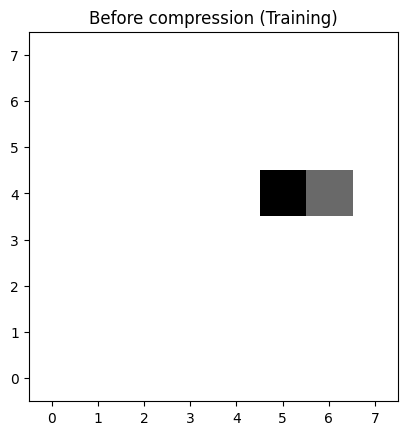

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 13.086 %


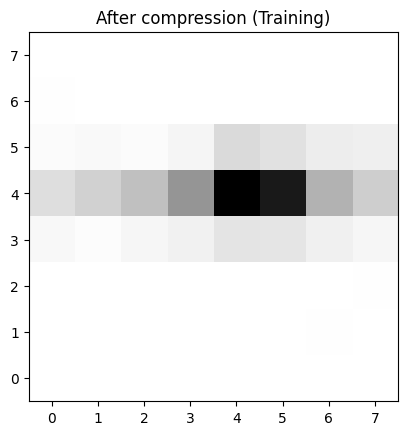

Epoch 182/200: 100%|██████████| 40/40 [00:00<00:00, 216.16it/s, Loss (BCE + VQ)=0.0532]


Epoch [182/200] summary:Average Loss: VQ + BCE = 0.0514,  Average loss: BCE = 0.0474 MSE = 0.004929418140091002 avg_perplexity = 60.489171504974365
Average validation set BCE loss: 0.04585406556725502


Epoch 183/200: 100%|██████████| 40/40 [00:00<00:00, 226.15it/s, Loss (BCE + VQ)=0.0507]


Epoch [183/200] summary:Average Loss: VQ + BCE = 0.0513,  Average loss: BCE = 0.0474 MSE = 0.004919892980251461 avg_perplexity = 61.32604694366455
Average validation set BCE loss: 0.04614691808819771


Epoch 184/200: 100%|██████████| 40/40 [00:00<00:00, 219.04it/s, Loss (BCE + VQ)=0.0494]


...

Epoch [194/200] summary:Average Loss: VQ + BCE = 0.0514,  Average loss: BCE = 0.0475 MSE = 0.004945601813960821 avg_perplexity = 60.85280570983887
Average validation set BCE loss: 0.0460965633392334


Epoch 195/200: 100%|██████████| 40/40 [00:00<00:00, 219.57it/s, Loss (BCE + VQ)=0.0493]


Epoch [195/200] summary:Average Loss: VQ + BCE = 0.0513,  Average loss: BCE = 0.0474 MSE = 0.00491999740479514 avg_perplexity = 61.03738660812378
Average validation set BCE loss: 0.046120550483465195


Epoch 196/200: 100%|██████████| 40/40 [00:00<00:00, 219.60it/s, Loss (BCE + VQ)=0.0492]


Epoch [196/200] summary:Average Loss: VQ + BCE = 0.0513,  Average loss: BCE = 0.0474 MSE = 0.004932125401683152 avg_perplexity = 60.884980869293216
Average validation set BCE loss: 0.04583894833922386
Before compression (Training)
Shape: (205, 8, 8)


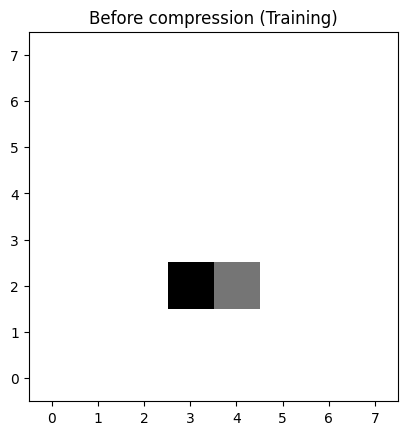

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 13.086 %


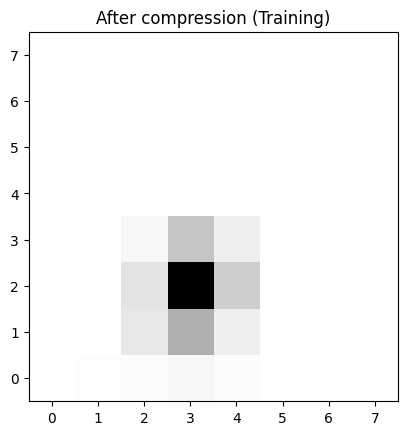

Epoch 197/200: 100%|██████████| 40/40 [00:00<00:00, 214.49it/s, Loss (BCE + VQ)=0.0487]


Epoch [197/200] summary:Average Loss: VQ + BCE = 0.0512,  Average loss: BCE = 0.0474 MSE = 0.00493585171061568 avg_perplexity = 60.955874824523924
Average validation set BCE loss: 0.0461924783885479


Epoch 198/200: 100%|██████████| 40/40 [00:00<00:00, 208.03it/s, Loss (BCE + VQ)=0.0518]


Epoch [198/200] summary:Average Loss: VQ + BCE = 0.0512,  Average loss: BCE = 0.0474 MSE = 0.00493104790803045 avg_perplexity = 60.92558717727661
Average validation set BCE loss: 0.04601491615176201


Epoch 199/200: 100%|██████████| 40/40 [00:00<00:00, 220.43it/s, Loss (BCE + VQ)=0.0521]


Epoch [199/200] summary:Average Loss: VQ + BCE = 0.0512,  Average loss: BCE = 0.0474 MSE = 0.00493031240766868 avg_perplexity = 60.87560844421387
Average validation set BCE loss: 0.04595395550131798


Epoch 200/200: 100%|██████████| 40/40 [00:00<00:00, 217.74it/s, Loss (BCE + VQ)=0.0506]


Epoch [200/200] summary:Average Loss: VQ + BCE = 0.0513,  Average loss: BCE = 0.0474 MSE = 0.004932528565404937 avg_perplexity = 61.01009635925293
Average validation set BCE loss: 0.04594980925321579
Before compression (Validation)
Shape: (317, 8, 8)


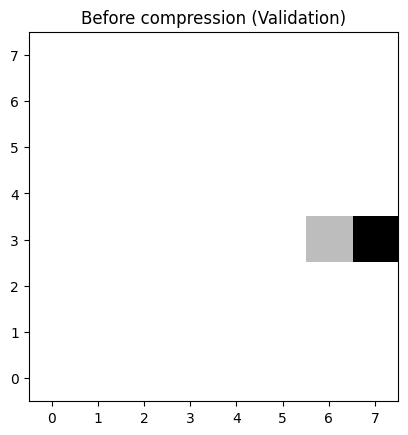

After compression (Validation)
Shape: (1, 8, 8)


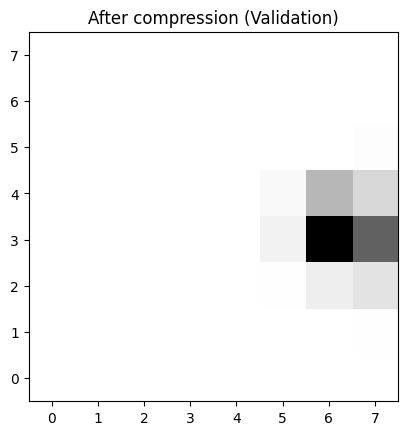

----------------------------------------
Patch = 0 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 1
Compression ratio = 3.797140064324904
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 20.0 (1 patch 8 x 8)
num_embeddings = 512
Codebook dimensions: 512 x 32
----------------------------------------
Saving trained model VQ-VAE


In [22]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            z,
            perplexity,
            vq_loss,
            usage
        ) = model(
           X_adcs,
           d
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,_
            ) = model(patch_val, d)
            
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = model_tool._tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                cms_plots.plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = model_tool._tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                print(f"Codebook usage percentage (Training): {usage:.3f} %")
                
                cms_plots.plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(
                        model_tool._tensor_to_numpy(codebook_train)
                    )
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _, _
                ) = model(patch_val, d)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = model_tool._tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                cms_plots.plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = model_tool._tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                cms_plots.plot_patch(
                    recon_patch_np_val[0], 
                    "After compression (Validation)"
                )
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = model_tool._tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                batch, indexes_enc, channel = z_q_val.shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------width_val------------------------")
                print(
                    f"Patch encoder output encoded into:"
                    f"codebook indexes = {indexes_enc}"
                )
                
            
                compression_ratio = cms_data_tool._get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(d, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
                    (
                        d,
                        num_embeddings
                    ), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "../bin/vqvae.pth")

<h3>VQ-VAE results analysis</h3>

In [23]:
total_bits = cms_data_tool._get_total_hit_bits(
    total_hit_amount
)


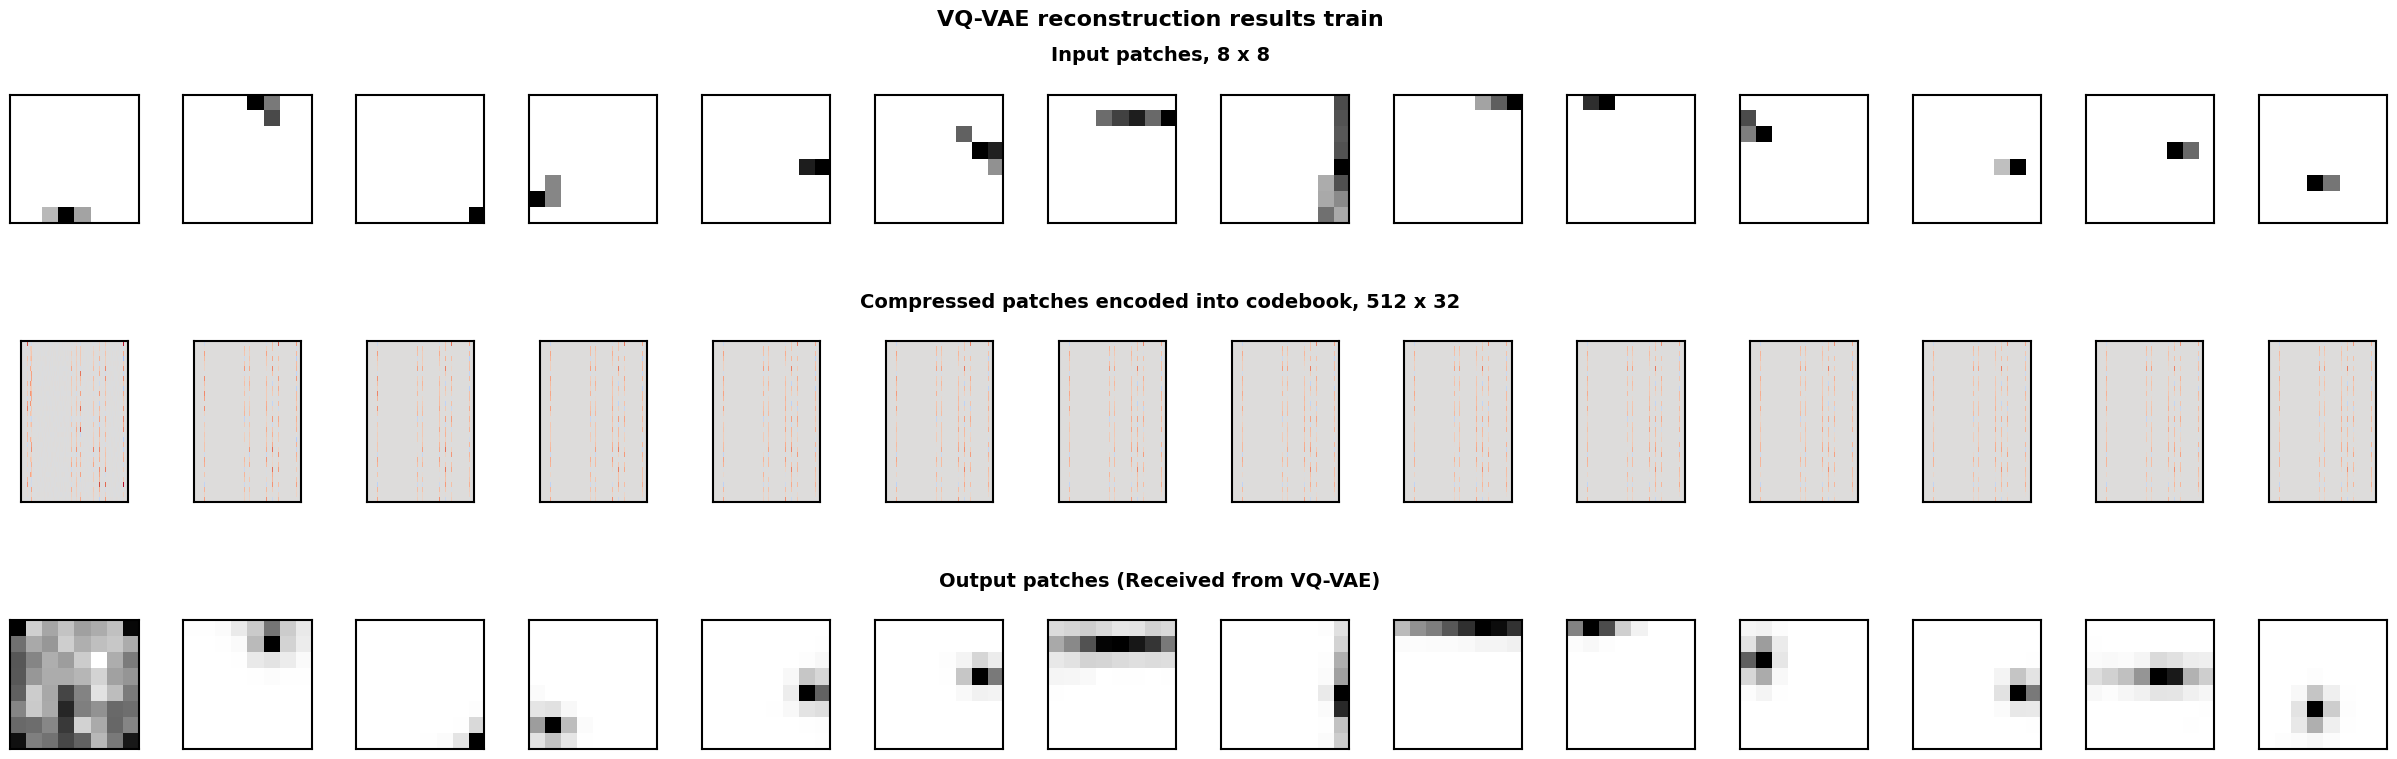

In [24]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train")

# NOTE: Some patches are blurry due to early collection in the epochs

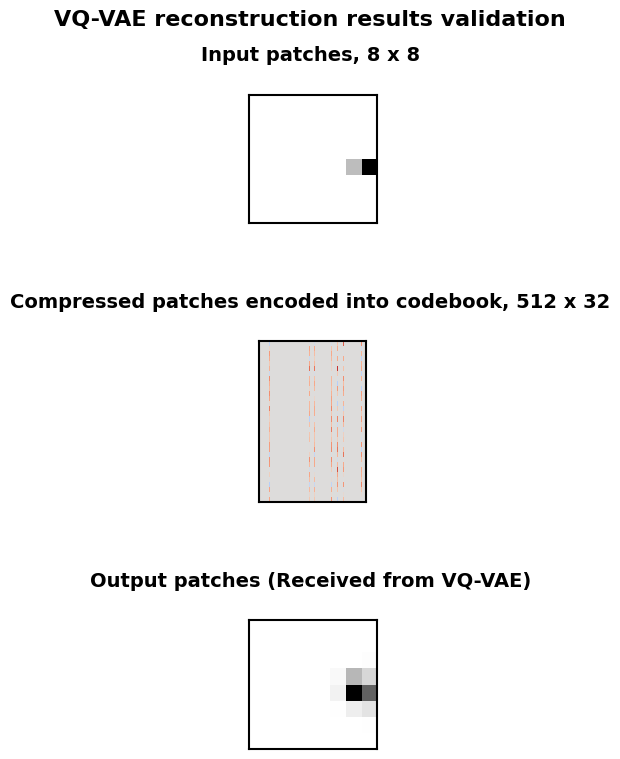

In [25]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results validation"
)

In [26]:
# TODO
# Improve gradients
model_tool._display_gradients(model)

Showing model gradients
encoder.0.weight 0.0026648682542145252
encoder.1.weight 0.0003488551010377705
encoder.1.bias 0.0005776752368547022
encoder.3.weight 0.010245746932923794
encoder.4.weight 0.00036829631426371634
encoder.4.bias 0.00042548103374429047
encoder.6.weight 0.012779505923390388
encoder.7.weight 0.0004308255738578737
encoder.7.bias 0.0008442797116003931
encoder.8.stack.0.res_block.1.weight 0.002951730042695999
encoder.8.stack.0.res_block.3.weight 0.0016087284311652184
encoder.8.stack.1.res_block.1.weight 0.0035382057540118694
encoder.8.stack.1.res_block.3.weight 0.0015503417234867811
fc_encoder_input.layers.0.weight 0.0023601423017680645
fc_encoder_input.layers.0.bias 1.2951204553246498e-09
fc_encoder_input.layers.1.weight 0.0029730722308158875
fc_encoder_input.layers.1.bias 0.006066998466849327
fc_decoder_input.layers.0.weight 0.0004999270313419402
fc_decoder_input.layers.0.bias 0.000909427588339895
fc_decoder_input.layers.1.weight 0.0007505016983486712
fc_decoder_input.l

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


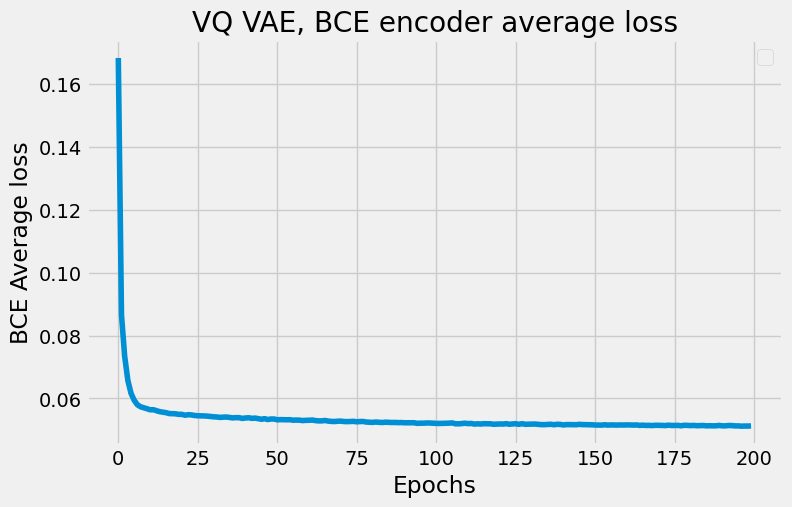

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [27]:
# display loss values
cms_plots.plot_curve(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [28]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("../bin/vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _, _
    ) = model(patch_test, d)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(
            model_tool._tensor_to_numpy(codebook_test)
        )
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 9), average BCE loss = 0.92279
Based on test set (size = 9), average codebook perplexity = 60.59803/512
Saved VQ-VAE test results


In [29]:
len(patches_before_test)

6

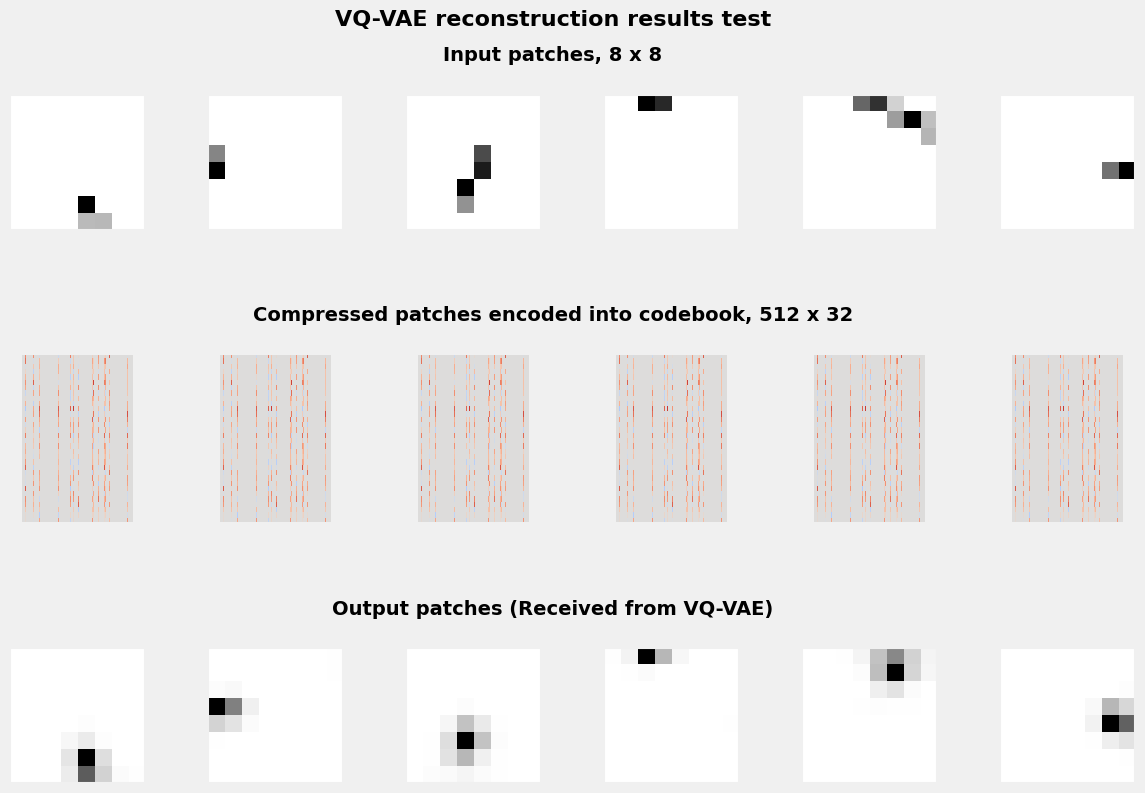

In [30]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test")

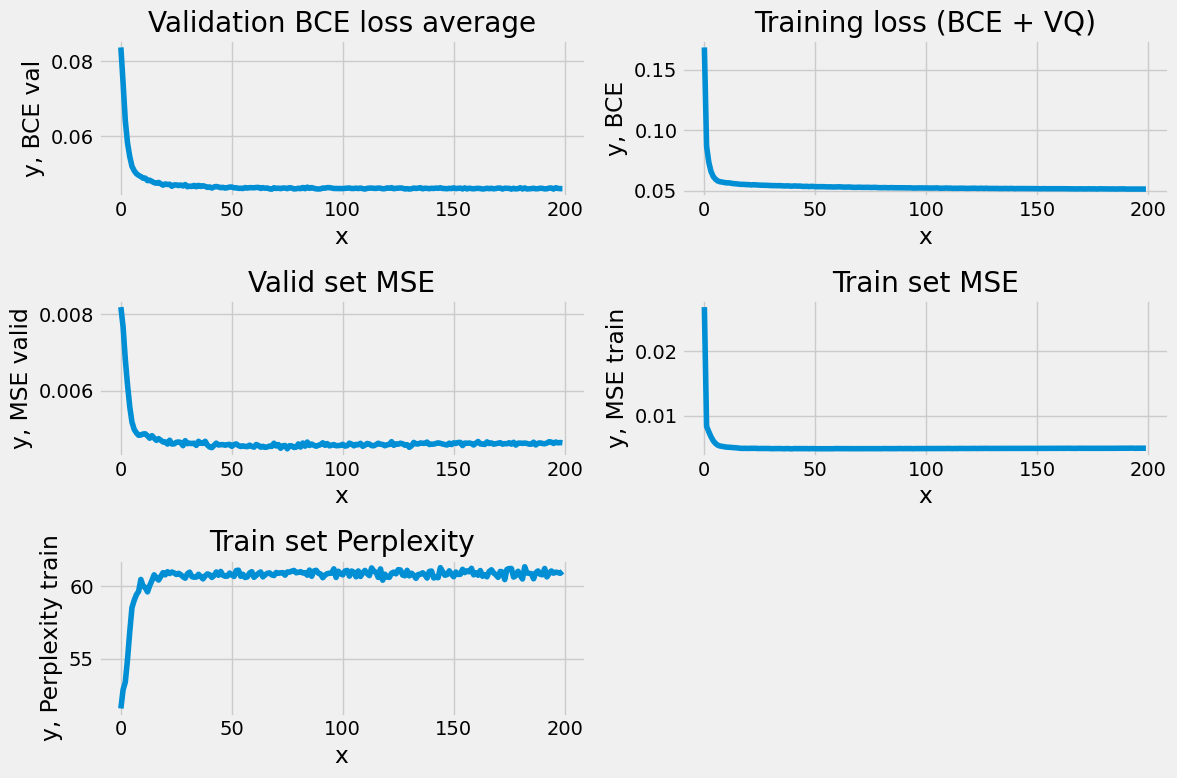

In [31]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

cms_plots.plot_curves(values_to_plot)


In [32]:
patches_before_train

[array([[0.        , 0.        , 0.1254902 , 0.45882353, 0.16470589,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ]], dtype=float32),
 array([[0.        , 0.        , 0.        , 0.        , 0.    

In [33]:
params = [
    p for name, p in model.named_parameters()
    if name != "vq.embedding.weight"
]
params

[Parameter containing:
 tensor([[[[-0.0169, -0.1287,  0.0747,  0.0098],
           [ 0.1486,  0.2254,  0.1349, -0.1222],
           [ 0.0204, -0.2518,  0.0052, -0.0473],
           [-0.0257, -0.0214,  0.0703, -0.2315]]],
 
 
         [[[ 0.1212,  0.1441,  0.0061, -0.1244],
           [ 0.0100, -0.2619,  0.0087, -0.1343],
           [ 0.0786,  0.0583, -0.0038,  0.0337],
           [ 0.1840, -0.0138,  0.0867,  0.1412]]],
 
 
         [[[-0.1504,  0.1153,  0.0208, -0.0153],
           [-0.0938,  0.1759,  0.0697,  0.0360],
           [-0.0796,  0.1520,  0.0310,  0.1822],
           [ 0.0840, -0.0931,  0.0923,  0.0039]]],
 
 
         ...,
 
 
         [[[-0.1871, -0.1928, -0.2326,  0.0868],
           [-0.4195, -0.2233,  0.0022, -0.2160],
           [ 0.0525, -0.1101,  0.1193,  0.2069],
           [ 0.0874, -0.1489,  0.1602,  0.0652]]],
 
 
         [[[-0.3194, -0.1198, -0.1408, -0.0701],
           [ 0.0425, -0.1722,  0.0579,  0.0773],
           [-0.2271, -0.0965, -0.1186,  0.1777],
    